# Trabajo práctico 2 - Minería de Datos - Modelo de Clasificación
Primer Cuatrimestre - Año 2026

Integrantes:

- Lara Onyskiw
- Sebastián Muñoz

### Importación de paquetes y carga del dataset

In [631]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

Agregamos esta ruta para que Python pueda encontrar el ejecutable de Graphviz y generar la visualización del árbol dentro del notebook.

In [632]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn.naive_bayes import CategoricalNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import KBinsDiscretizer, OrdinalEncoder
from graphviz import Source
from matplotlib.colors import LinearSegmentedColormap


Ignoramos este warning visual porque usamos una misma paleta de verdes en gráficos con distinta cantidad de categorías. La advertencia no afecta los datos ni el resultado del análisis, solo indica que la paleta tiene más colores que los necesarios en algunos casos.

In [633]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### Análisis exploratorio y limpieza de datos

In [634]:
dataDrug = pd.read_csv("drugType.csv")

dataDrug.head()

,Edad,Sexo,BP,Colesterol,Na_a_K,Droga
0,23,F,Alto,Alto,25.355,DrogaY
1,47,M,Bajo,Alto,13.093,DrogaC
2,47,M,Bajo,Alto,10.114,DrogaC
3,28,F,Normal,Alto,7.798,DrogaX
4,61,F,Bajo,Alto,18.043,DrogaY


In [635]:
print(f"Filas, columnas: {dataDrug.shape} \n ")
print(f"Tipos de datos: \n {dataDrug.dtypes}")

Filas, columnas: (200, 6) 
 
Tipos de datos: 
 Edad            int64
Sexo              str
BP                str
Colesterol        str
Na_a_K        float64
Droga             str
dtype: object


In [636]:
# Faltantes
print(f"Cantidad de valores nulos por columna: \n {dataDrug.isna().sum()}")

Cantidad de valores nulos por columna: 
 Edad          0
Sexo          0
BP            0
Colesterol    0
Na_a_K        0
Droga         0
dtype: int64


In [637]:
print(f"Cantidad de registros duplicados: {dataDrug.duplicated().sum()}")

display(dataDrug[dataDrug.duplicated(keep=False)].sort_values(by=list(dataDrug.columns)))

Cantidad de registros duplicados: 0


,Edad,Sexo,BP,Colesterol,Na_a_K,Droga


A partir de la revisión inicial observamos que el dataset contiene 200 registros y 6 columnas. No se detectaron valores faltantes ni registros duplicados, por lo que en esta primera instancia no necesitamos aplicar imputaciones ni eliminar filas por redundancia.

Los tipos de datos fueron leídos de forma coherente: 'Edad' aparece como variable numérica entera, 'Na_a_K' como variable numérica continua, y 'Sexo', 'BP', 'Colesterol' y 'Droga' como variables categóricas.

Desde el punto de vista del problema, 'Droga' será la variable objetivo, ya que buscamos predecir el tipo de medicamento. Las demás columnas serán utilizadas como variables predictoras.

In [638]:
# Paleta de colores utilizada en el TP
paleta = ["#86c686", "#9ce29c", "#6fbd7f", "#4f9d69", "#2f6f46"]

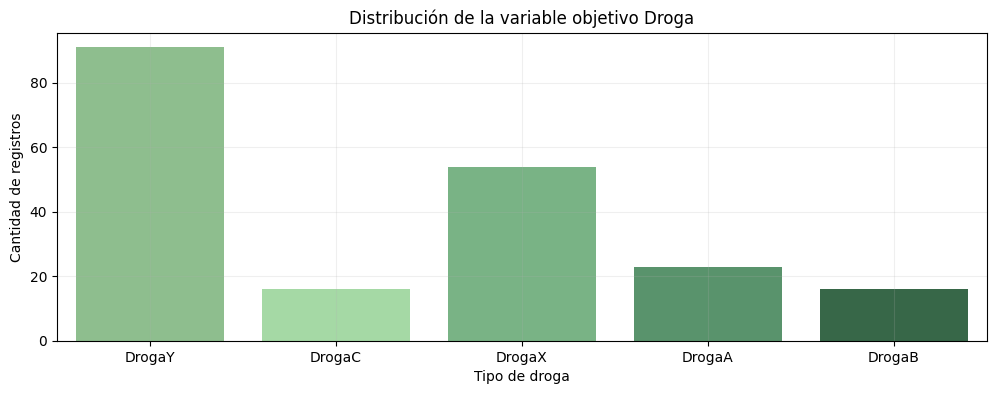

In [639]:
dataDrug["Droga"].value_counts()

plt.figure(figsize=(12, 4))

sns.countplot(
    data=dataDrug,
    x="Droga",
    hue="Droga",
    palette=paleta,
    legend=False
)

plt.title("Distribución de la variable objetivo Droga")
plt.xlabel("Tipo de droga")
plt.ylabel("Cantidad de registros")
plt.grid(alpha=0.2)
plt.show()

Al observar la distribución de la variable objetivo 'Droga', vemos que las clases no se encuentran equilibradas. 'DrogaY' es la categoría con mayor cantidad de registros, seguida por 'DrogaX', mientras que 'DrogaC' y 'DrogaB' aparecen con una frecuencia bastante menor.

Esta diferencia entre clases es relevante porque puede influir en el entrenamiento y en la evaluación de los modelos de clasificación. Por este motivo, más adelante utilizaremos particiones estratificadas, de manera que los conjuntos de entrenamiento y prueba conserven una proporción similar de cada tipo de droga.

In [640]:
dataDrug[["Edad", "Na_a_K"]].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.995])

,Edad,Na_a_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
95%,70.100000,30.623900
99.5%,74.000000,37.193295
max,74.000000,38.247000


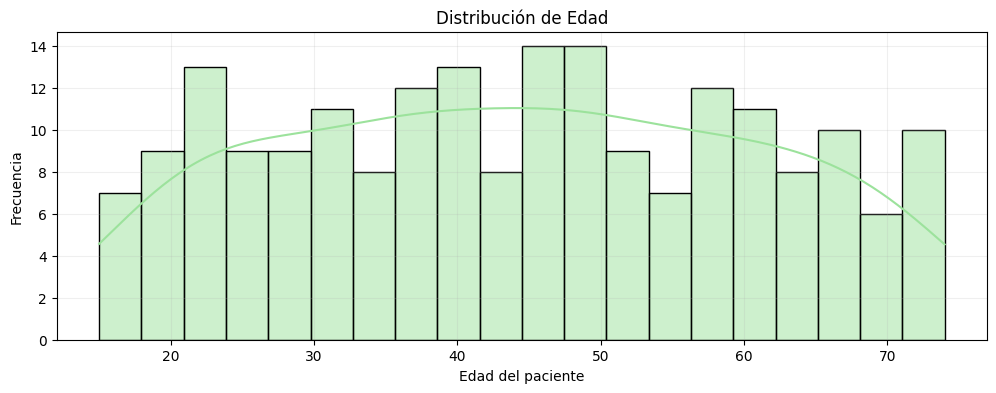

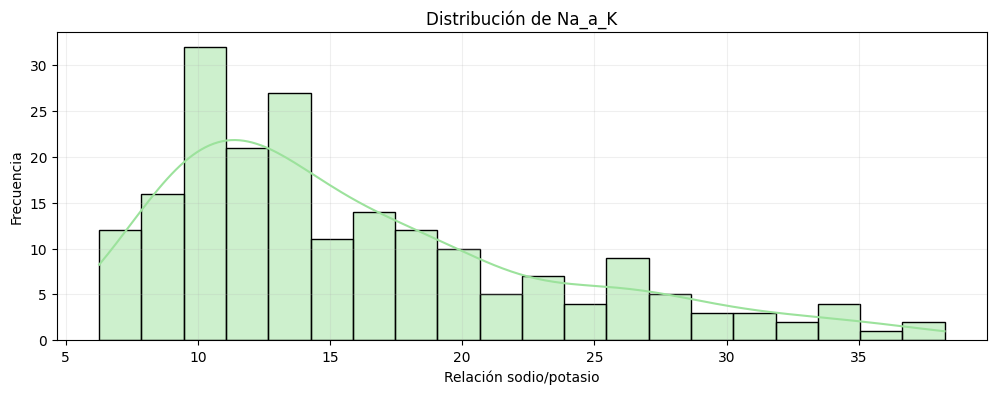

In [641]:
cols_numericas_drug = ["Edad", "Na_a_K"]

etiquetas_drug = {
    "Edad": "Edad del paciente",
    "Na_a_K": "Relación sodio/potasio"
}

for col in cols_numericas_drug:
    plt.figure(figsize=(12, 4))

    sns.histplot(
        data=dataDrug,
        x=col,
        bins=20,
        kde=True,
        color="#9ce29c"
    )

    plt.title("Distribución de " + col)
    plt.xlabel(etiquetas_drug[col])
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.2)
    plt.show()

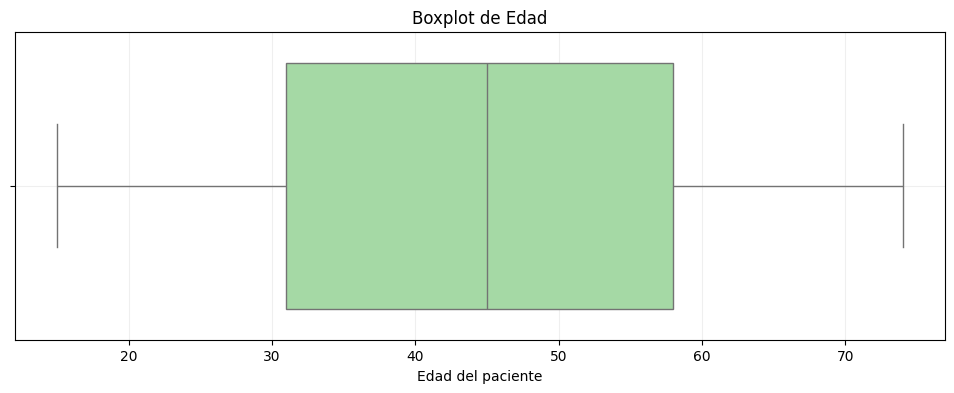

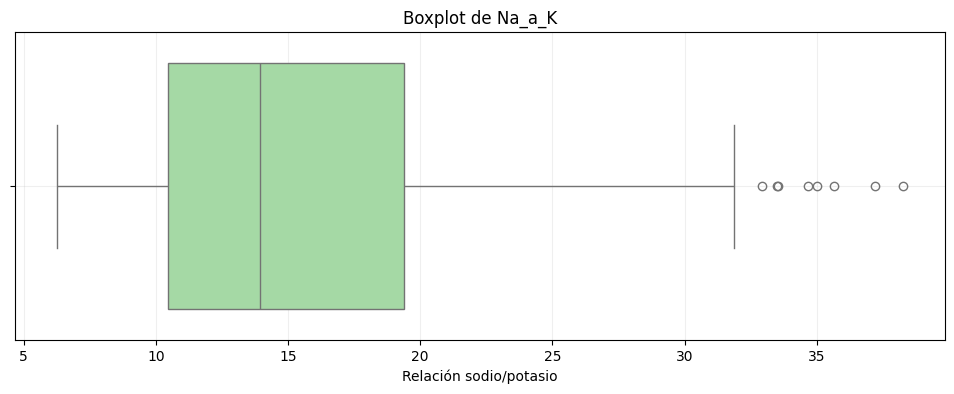

In [642]:
for col in cols_numericas_drug:
    plt.figure(figsize=(12, 4))

    sns.boxplot(
        data=dataDrug,
        x=col,
        color="#9ce29c"
    )

    plt.title("Boxplot de " + col)
    plt.xlabel(etiquetas_drug[col])
    plt.grid(alpha=0.2)
    plt.show()

Al revisar las variables numéricas observamos que 'Edad' se distribuye de manera bastante amplia entre los 15 y los 74 años, sin valores extremos marcados en el boxplot. Por este motivo, no consideramos necesario realizar ningún tratamiento sobre esta variable.

En cambio, 'Na_a_K' presenta una distribución asimétrica hacia la derecha: la mayoría de los registros se concentra en valores bajos y medios, pero aparecen algunos valores altos alejados del rango central. Aunque el boxplot los marca como posibles outliers, decidimos conservarlos, ya que no parecen ser errores de carga y podrían ser relevantes para diferenciar ciertos tipos de droga.

A partir de esta revisión, continuamos con el análisis de las variables categóricas predictoras: 'Sexo', 'BP' y 'Colesterol'.

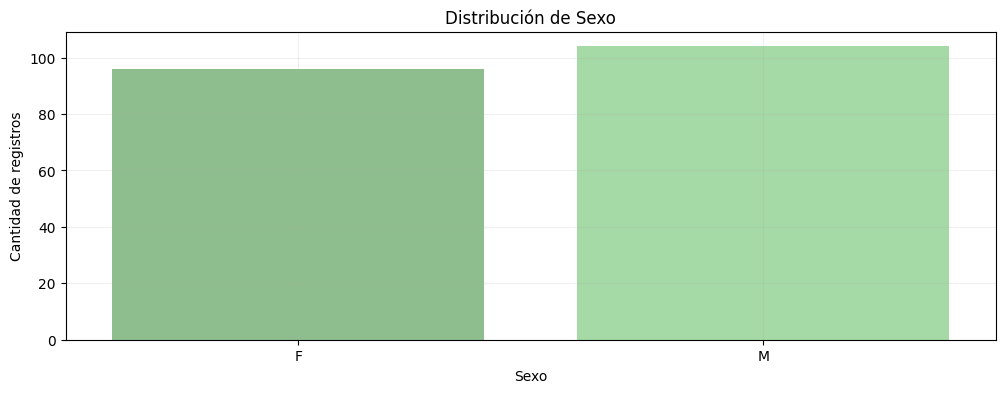

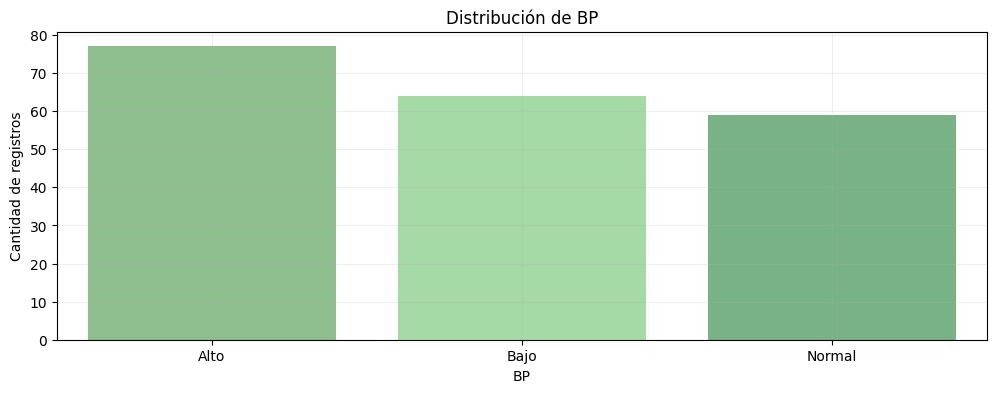

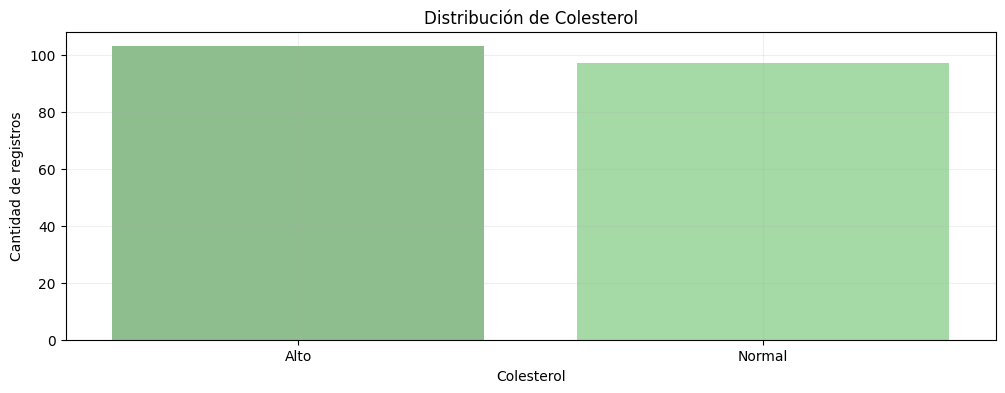

In [643]:
cols_categoricas_drug = ["Sexo", "BP", "Colesterol"]

for col in cols_categoricas_drug:
    plt.figure(figsize=(12, 4))

    sns.countplot(
        data=dataDrug,
        x=col,
        hue=col,
        palette=paleta,
        legend=False
    )

    plt.title("Distribución de " + col)
    plt.xlabel(col)
    plt.ylabel("Cantidad de registros")
    plt.grid(alpha=0.2)
    plt.show()

In [644]:
for col in cols_categoricas_drug:
    print("\nTabla cruzada entre", col, "y Droga")
    display(pd.crosstab(dataDrug[col], dataDrug["Droga"]))


Tabla cruzada entre Sexo y Droga


Droga,DrogaA,DrogaB,DrogaC,DrogaX,DrogaY
Sexo,,,,,
F,9,6,7,27,47
M,14,10,9,27,44



Tabla cruzada entre BP y Droga


Droga,DrogaA,DrogaB,DrogaC,DrogaX,DrogaY
BP,,,,,
Alto,23,16,0,0,38
Bajo,0,0,16,18,30
Normal,0,0,0,36,23



Tabla cruzada entre Colesterol y Droga


Droga,DrogaA,DrogaB,DrogaC,DrogaX,DrogaY
Colesterol,,,,,
Alto,12,8,16,20,47
Normal,11,8,0,34,44


Al observar las variables categóricas, vemos que 'Sexo' se encuentra bastante equilibrada entre las categorías 'F' y 'M'. Por este motivo, no parece haber un desbalance importante en esta variable.

En 'BP', la categoría 'Alto' es la más frecuente, seguida por 'Bajo' y 'Normal', aunque las diferencias no son extremas. En cambio, 'Colesterol' presenta una distribución prácticamente equilibrada entre 'Alto' y 'Normal'.

Las tablas cruzadas aportan una lectura más vinculada con la variable objetivo. En 'Sexo', la distribución de las drogas es bastante similar entre hombres y mujeres, por lo que no observamos una separación clara de clases. En cambio, 'BP' sí parece tener mayor relación con 'Droga': por ejemplo, 'DrogaA' y 'DrogaB' aparecen asociadas a presión alta, mientras que 'DrogaC' aparece únicamente en pacientes con presión baja. También observamos que 'DrogaX' se concentra en presión baja y normal.

En el caso de 'Colesterol', la diferencia más marcada se da en 'DrogaC', que solo aparece cuando el colesterol es alto. A partir de estas observaciones, consideramos que 'BP' y 'Colesterol' podrían aportar información relevante al modelo de clasificación, mientras que 'Sexo' parece tener un peso menor.

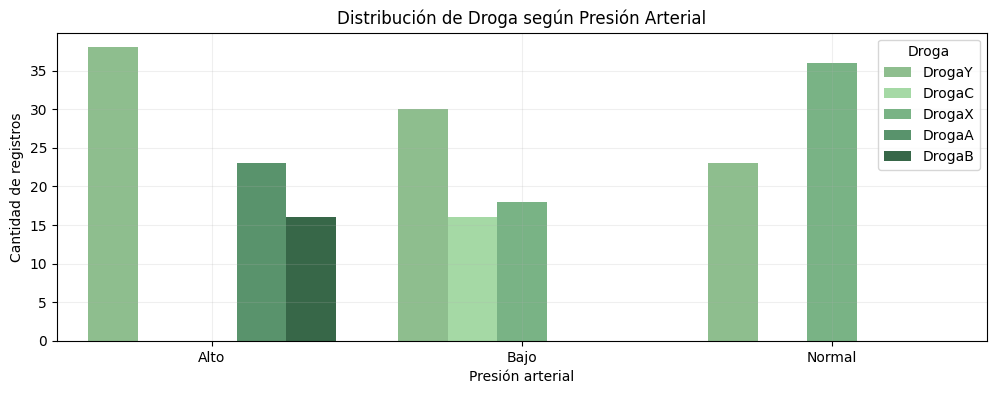

In [645]:
plt.figure(figsize=(12, 4))

sns.countplot(
    data=dataDrug,
    x="BP",
    hue="Droga",
    palette=paleta
)

plt.title("Distribución de Droga según Presión Arterial")
plt.xlabel("Presión arterial")
plt.ylabel("Cantidad de registros")
plt.grid(alpha=0.2)
plt.show()

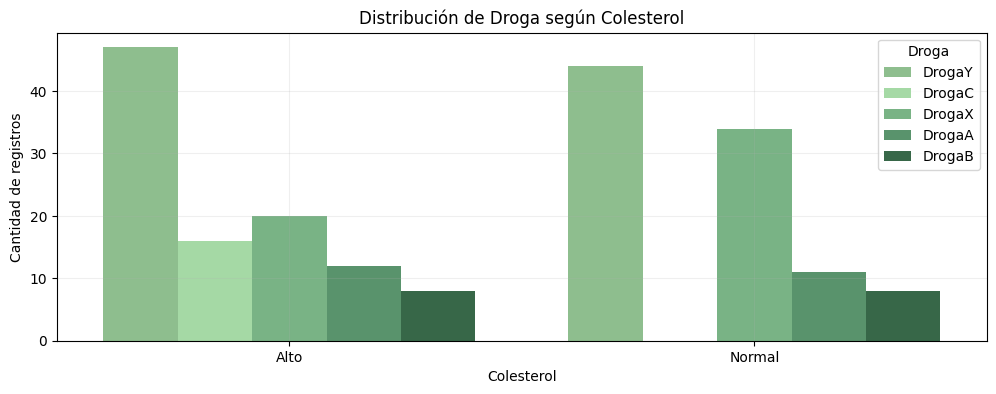

In [646]:
plt.figure(figsize=(12, 4))

sns.countplot(
    data=dataDrug,
    x="Colesterol",
    hue="Droga",
    palette=paleta
)

plt.title("Distribución de Droga según Colesterol")
plt.xlabel("Colesterol")
plt.ylabel("Cantidad de registros")
plt.grid(alpha=0.2)
plt.show()

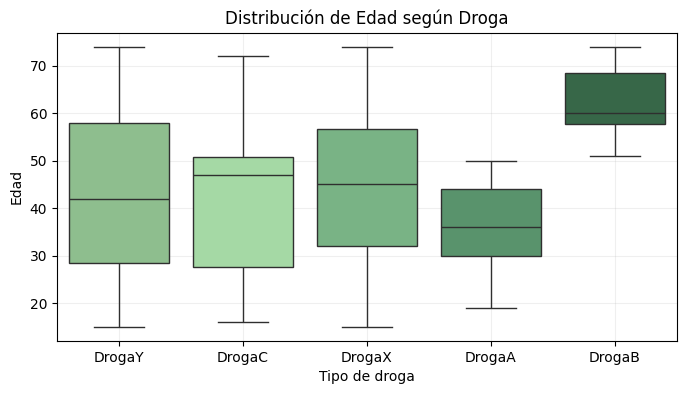

In [647]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=dataDrug,
    x="Droga",
    y="Edad",
    hue="Droga",
    palette=paleta,
    legend=False
)

plt.title("Distribución de Edad según Droga")
plt.xlabel("Tipo de droga")
plt.ylabel("Edad")
plt.grid(alpha=0.2)
plt.show()

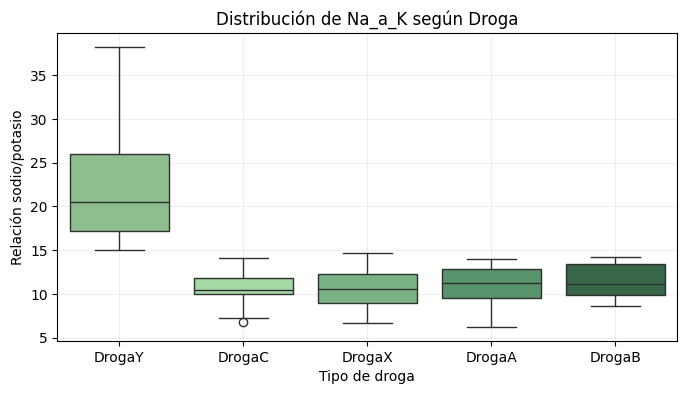

In [648]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=dataDrug,
    x="Droga",
    y="Na_a_K",
    hue="Droga",
    palette=paleta,
    legend=False
)

plt.title("Distribución de Na_a_K según Droga")
plt.xlabel("Tipo de droga")
plt.ylabel("Relación sodio/potasio")
plt.grid(alpha=0.2)
plt.show()

Al cruzar las variables predictoras con 'Droga', observamos patrones más claros que en las distribuciones individuales.

En el caso de 'BP', vemos que algunas drogas aparecen asociadas a ciertos niveles de presión arterial. 'DrogaA' y 'DrogaB' se presentan únicamente cuando la presión es alta, mientras que 'DrogaC' aparece en pacientes con presión baja. 'DrogaX' se concentra en presión baja y normal, y 'DrogaY' aparece en los tres niveles, aunque con mayor presencia general.

Con 'Colesterol' también encontramos diferencias relevantes. 'DrogaC' aparece únicamente en pacientes con colesterol alto, mientras que 'DrogaX' tiene mayor presencia cuando el colesterol es normal. En cambio, 'DrogaY' se distribuye de forma similar entre colesterol alto y normal.

Al analizar las variables numéricas por tipo de droga, 'Edad' muestra algunas diferencias entre grupos, especialmente en 'DrogaB', que se concentra en pacientes de mayor edad, y 'DrogaA', que aparece en edades más bajas. Sin embargo, la separación más marcada se observa en 'Na_a_K': los valores de esta variable son claramente más altos para 'DrogaY', mientras que el resto de las drogas se mantiene en rangos más bajos y cercanos entre sí.

A partir de estas observaciones, consideramos que 'Na_a_K', 'BP' y 'Colesterol' parecen ser variables relevantes para la clasificación. 'Edad' también puede aportar información en algunos casos.

Con este análisis exploratorio dejamos identificadas las principales características del dataset. Verificamos que no existen valores faltantes ni registros duplicados, y que los tipos de datos fueron leídos correctamente.

También observamos que la variable objetivo 'Droga' presenta cierto desbalance: 'DrogaY' es la clase más frecuente, mientras que 'DrogaB' y 'DrogaC' tienen menos registros. Por este motivo, en la preparación de datos utilizaremos particiones estratificadas, para conservar proporciones similares de clases en entrenamiento y prueba.

En cuanto a las variables predictoras, 'Na_a_K' muestra una separación clara para 'DrogaY', con valores más altos que en el resto de las clases. Además, 'BP' y 'Colesterol' presentan asociaciones visibles con ciertos tipos de droga, especialmente en los casos de 'DrogaA', 'DrogaB' y 'DrogaC'. En cambio, 'Sexo' no muestra una diferenciación marcada entre clases.

### Codificación, estandarización y particiones del dataset

In [649]:
# Separamos variables predictoras y variable objetivo
X = dataDrug.drop("Droga", axis=1)
y = dataDrug["Droga"]

# Codificamos las variables categóricas predictoras
X = pd.get_dummies(X, columns=["Sexo", "BP", "Colesterol"], dtype=int)

X.head()

,Edad,Na_a_K,Sexo_F,Sexo_M,BP_Alto,BP_Bajo,BP_Normal,Colesterol_Alto,Colesterol_Normal
0,23,25.355,1,0,1,0,0,1,0
1,47,13.093,0,1,0,1,0,1,0
2,47,10.114,0,1,0,1,0,1,0
3,28,7.798,1,0,0,0,1,1,0
4,61,18.043,1,0,0,1,0,1,0


Codificamos las variables categóricas predictoras mediante variables dummies para que puedan ser utilizadas por los modelos de clasificación. En este caso no codificamos 'Droga', ya que se mantiene como variable objetivo.

In [650]:
# Generamos las particiones con estratificación por la variable objetivo

X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=63,
    stratify=y
)

X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=63,
    stratify=y
)

print("Partición 80/20")
print("X_train_80:", X_train_80.shape)
print("X_test_20:", X_test_20.shape)
print("y_train_80:", y_train_80.shape)
print("y_test_20:", y_test_20.shape)

print("\nPartición 70/30")
print("X_train_70:", X_train_70.shape)
print("X_test_30:", X_test_30.shape)
print("y_train_70:", y_train_70.shape)
print("y_test_30:", y_test_30.shape)

Partición 80/20
X_train_80: (160, 9)
X_test_20: (40, 9)
y_train_80: (160,)
y_test_20: (40,)

Partición 70/30
X_train_70: (140, 9)
X_test_30: (60, 9)
y_train_70: (140,)
y_test_30: (60,)


Generamos dos particiones del dataset, una 80/20 y otra 70/30, utilizando 'random_state=63' para asegurar reproducibilidad. Como observamos desbalance en la variable objetivo, aplicamos estratificación por 'Droga', de manera que los conjuntos de entrenamiento y prueba mantengan una distribución de clases similar a la original.

In [651]:
# Estandarizamos únicamente las variables numéricas
numeric_features_drug = ["Edad", "Na_a_K"]

X_train_80_scaled = X_train_80.copy()
X_test_20_scaled = X_test_20.copy()

scaler_80 = StandardScaler()

X_train_80_scaled[numeric_features_drug] = scaler_80.fit_transform(
    X_train_80_scaled[numeric_features_drug]
)

X_test_20_scaled[numeric_features_drug] = scaler_80.transform(
    X_test_20_scaled[numeric_features_drug]
)

In [652]:
X_train_70_scaled = X_train_70.copy()
X_test_30_scaled = X_test_30.copy()

scaler_70 = StandardScaler()

X_train_70_scaled[numeric_features_drug] = scaler_70.fit_transform(
    X_train_70_scaled[numeric_features_drug]
)

X_test_30_scaled[numeric_features_drug] = scaler_70.transform(
    X_test_30_scaled[numeric_features_drug]
)

La estandarización se aplicó solo sobre 'Edad' y 'Na_a_K', ya que son las variables numéricas del dataset. Ajustamos el escalador únicamente con los datos de entrenamiento y luego aplicamos esa transformación sobre el conjunto de prueba, evitando que la información del test intervenga en la preparación del modelo.

### Árbol de decisión para clasificación

Habiendo preparado el dataset, comenzamos con la estimación de la variable 'Droga' utilizando árboles de decisión para clasificación. En esta primera aproximación entrenamos un modelo base.

El objetivo inicial es verificar que las particiones, la codificación de variables categóricas y la estandarización de las variables numéricas hayan quedado correctamente integradas. Luego, avanzaremos con la exploración sistemática de hiperparámetros y con la poda del árbol.

In [653]:
# Árbol de decisión - Clasificación 80/20 

tree_clf_80 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=63
)

tree_clf_80.fit(X_train_80_scaled, y_train_80)

y_pred_80 = tree_clf_80.predict(X_test_20_scaled)

print("Precision:", metrics.precision_score(y_test_20, y_pred_80, average="macro"))
print("Recall:", metrics.recall_score(y_test_20, y_pred_80, average="macro"))
print("Accuracy:", metrics.accuracy_score(y_test_20, y_pred_80))


Precision: 1.0
Recall: 1.0
Accuracy: 1.0


In [654]:
# Árbol de decisión - Clasificación 70/30 

tree_clf_70 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=63
)

tree_clf_70.fit(X_train_70_scaled, y_train_70)

y_pred_70 = tree_clf_70.predict(X_test_30_scaled)

print("Precision:", metrics.precision_score(y_test_30, y_pred_70, average="macro"))
print("Recall:", metrics.recall_score(y_test_30, y_pred_70, average="macro"))
print("Accuracy:", metrics.accuracy_score(y_test_30, y_pred_70))

Precision: 1.0
Recall: 1.0
Accuracy: 1.0


En esta primera prueba con ambas particiones, el árbol de decisión base obtuvo valores de 'Precision', 'Recall' y 'Accuracy' iguales a 1.0. Este resultado indica que el modelo clasificó correctamente todas las observaciones del conjunto de prueba.

De todos modos, no tomamos este modelo como definitivo todavía. Esta primera ejecución funciona como referencia inicial, continuamos con la búsqueda de hiperparámetros para verificar si el desempeño se mantiene estable y para seleccionar una configuración justificada.

In [655]:
# Árbol de decisión - Clasificación 80/20 - Hiperparámetros 

resultados_tree_80 = []

max_depth_values = [2, 3, 4, 5]
min_samples_leaf_values = [1, 3, 5]
min_samples_split_values = [2, 5, 10]

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        for min_samples_split in min_samples_split_values:
            
            tree_clf = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                min_samples_split=min_samples_split,
                random_state=63
            )
            
            tree_clf.fit(X_train_80_scaled, y_train_80)
            
            y_pred = tree_clf.predict(X_test_20_scaled)
            
            precision = metrics.precision_score(
                y_test_20,
                y_pred,
                average="macro",
                zero_division=0
            )
            
            recall = metrics.recall_score(
                y_test_20,
                y_pred,
                average="macro",
                zero_division=0
            )
            
            accuracy = metrics.accuracy_score(y_test_20, y_pred)
            
            resultados_tree_80.append({
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "min_samples_split": min_samples_split,
                "Precision": precision,
                "Recall": recall,
                "Accuracy": accuracy
            })

resultados_tree_80 = pd.DataFrame(resultados_tree_80)

resultados_tree_80.sort_values(
    by=["Accuracy", "Recall", "Precision"],
    ascending=False
).head(10)

,max_depth,min_samples_leaf,min_samples_split,Precision,Recall,Accuracy
18,4,1,2,1.0,1.0,1.0
19,4,1,5,1.0,1.0,1.0
20,4,1,10,1.0,1.0,1.0
21,4,3,2,1.0,1.0,1.0
22,4,3,5,1.0,1.0,1.0
23,4,3,10,1.0,1.0,1.0
24,4,5,2,1.0,1.0,1.0
25,4,5,5,1.0,1.0,1.0
26,4,5,10,1.0,1.0,1.0
27,5,1,2,1.0,1.0,1.0


In [656]:
# Árbol de decisión - Clasificación 70/30 - Hiperparámetros 

resultados_tree_70 = []

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        for min_samples_split in min_samples_split_values:
            
            tree_clf = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                min_samples_split=min_samples_split,
                random_state=63
            )
            
            tree_clf.fit(X_train_70_scaled, y_train_70)
            
            y_pred = tree_clf.predict(X_test_30_scaled)
            
            precision = metrics.precision_score(
                y_test_30,
                y_pred,
                average="macro",
                zero_division=0
            )
            
            recall = metrics.recall_score(
                y_test_30,
                y_pred,
                average="macro",
                zero_division=0
            )
            
            accuracy = metrics.accuracy_score(y_test_30, y_pred)
            
            resultados_tree_70.append({
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "min_samples_split": min_samples_split,
                "Precision": precision,
                "Recall": recall,
                "Accuracy": accuracy
            })

resultados_tree_70 = pd.DataFrame(resultados_tree_70)

resultados_tree_70.sort_values(
    by=["Accuracy", "Recall", "Precision"],
    ascending=False
).head(10)

,max_depth,min_samples_leaf,min_samples_split,Precision,Recall,Accuracy
18,4,1,2,1.0,1.0,1.0
19,4,1,5,1.0,1.0,1.0
20,4,1,10,1.0,1.0,1.0
21,4,3,2,1.0,1.0,1.0
22,4,3,5,1.0,1.0,1.0
23,4,3,10,1.0,1.0,1.0
24,4,5,2,1.0,1.0,1.0
25,4,5,5,1.0,1.0,1.0
26,4,5,10,1.0,1.0,1.0
27,5,1,2,1.0,1.0,1.0


In [657]:
X.columns

Index(['Edad', 'Na_a_K', 'Sexo_F', 'Sexo_M', 'BP_Alto', 'BP_Bajo', 'BP_Normal',
       'Colesterol_Alto', 'Colesterol_Normal'],
      dtype='str')

In [658]:
# Revisamos si todas las combinaciones dieron 1.0 o solo las mejores
resultados_tree_80.sort_values(
    by=["Accuracy", "Recall", "Precision"],
    ascending=True
).head(10)

,max_depth,min_samples_leaf,min_samples_split,Precision,Recall,Accuracy
0,2,1,2,0.482143,0.6,0.850
1,2,1,5,0.482143,0.6,0.850
2,2,1,10,0.482143,0.6,0.850
3,2,3,2,0.482143,0.6,0.850
4,2,3,5,0.482143,0.6,0.850
5,2,3,10,0.482143,0.6,0.850
6,2,5,2,0.482143,0.6,0.850
7,2,5,5,0.482143,0.6,0.850
8,2,5,10,0.482143,0.6,0.850
9,3,1,2,0.757143,0.8,0.925


In [659]:
resultados_tree_70.sort_values(
    by=["Accuracy", "Recall", "Precision"],
    ascending=True
).head(10)

,max_depth,min_samples_leaf,min_samples_split,Precision,Recall,Accuracy
0,2,1,2,0.469048,0.6,0.833333
1,2,1,5,0.469048,0.6,0.833333
2,2,1,10,0.469048,0.6,0.833333
3,2,3,2,0.469048,0.6,0.833333
4,2,3,5,0.469048,0.6,0.833333
5,2,3,10,0.469048,0.6,0.833333
6,2,5,2,0.469048,0.6,0.833333
7,2,5,5,0.469048,0.6,0.833333
8,2,5,10,0.469048,0.6,0.833333
9,3,1,2,0.752381,0.8,0.916667


Al revisar los resultados de la búsqueda de hiperparámetros, observamos que varias configuraciones alcanzan valores de 'Precision', 'Recall' y 'Accuracy' iguales a 1.0 en ambas particiones. En principio esto podría llamar la atención, por lo que verificamos que la variable objetivo 'Droga' no haya quedado incluida entre las variables predictoras y que los modelos no estén dando 1.0 en todas las configuraciones, sino solo mostrando las mejores.

Una vez descartadas esas posibilidades, interpretamos que el resultado se debe a que el dataset presenta patrones de separación bastante claros, especialmente a partir de 'Na_a_K', 'BP' y 'Colesterol', tal como habíamos observado en el análisis exploratorio.

Como varias configuraciones obtienen el mismo desempeño, no elegimos el árbol más complejo. Priorizamos una configuración simple y conservadora, seleccionando 'max_depth=4', 'min_samples_leaf=5' y 'min_samples_split=2', ya que logra el mejor resultado manteniendo una estructura más controlada.

In [660]:
# Paleta para matrices de confusión: de blanco a verde oscuro
cmap_confusion = LinearSegmentedColormap.from_list(
    "cmap_confusion",
    ["#ffffff", "#6fbd7f", "#2f6f46"]
)

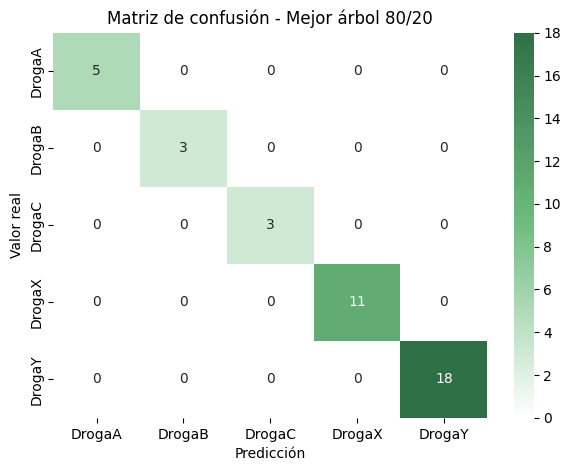

Precision: 1.0
Recall: 1.0
Accuracy: 1.0


In [661]:
# Árbol de decisión - Clasificación 80/20 - Mejor modelo 

best_tree_80 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=63
)

best_tree_80.fit(X_train_80_scaled, y_train_80)

y_pred_best_80 = best_tree_80.predict(X_test_20_scaled)

cm_best_80 = metrics.confusion_matrix(y_test_20, y_pred_best_80)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_best_80,
    annot=True,
    fmt="d",
    cmap=cmap_confusion,
    vmin=0,
    vmax=cm_best_80.max(),
    xticklabels=best_tree_80.classes_,
    yticklabels=best_tree_80.classes_
)

plt.title("Matriz de confusión - Mejor árbol 80/20")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

print("Precision:", metrics.precision_score(y_test_20, y_pred_best_80, average="macro"))
print("Recall:", metrics.recall_score(y_test_20, y_pred_best_80, average="macro"))
print("Accuracy:", metrics.accuracy_score(y_test_20, y_pred_best_80))

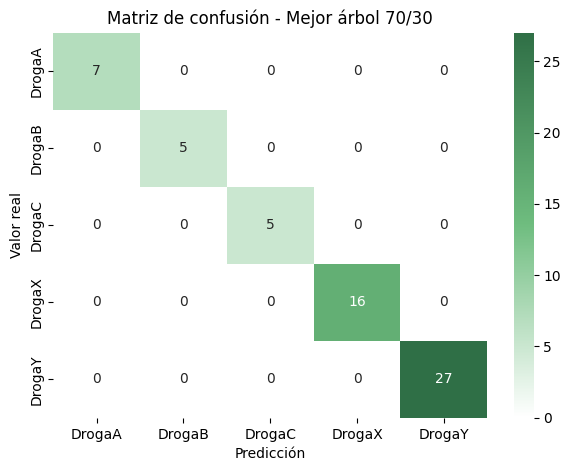

Precision: 1.0
Recall: 1.0
Accuracy: 1.0


In [662]:
# Árbol de decisión - Clasificación 70/30 - Mejor modelo 

best_tree_70 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=63
)

best_tree_70.fit(X_train_70_scaled, y_train_70)

y_pred_best_70 = best_tree_70.predict(X_test_30_scaled)

cm_best_70 = metrics.confusion_matrix(y_test_30, y_pred_best_70)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_best_70,
    annot=True,
    fmt="d",
    cmap=cmap_confusion,
    vmin=0,
    vmax=cm_best_70.max(),
    xticklabels=best_tree_70.classes_,
    yticklabels=best_tree_70.classes_
)

plt.title("Matriz de confusión - Mejor árbol 70/30")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


print("Precision:", metrics.precision_score(y_test_30, y_pred_best_70, average="macro"))
print("Recall:", metrics.recall_score(y_test_30, y_pred_best_70, average="macro"))
print("Accuracy:", metrics.accuracy_score(y_test_30, y_pred_best_70))

In [663]:
metricas_tree = pd.DataFrame({
    "Partición": ["80/20", "70/30"],
    "Precision": [
        metrics.precision_score(y_test_20, y_pred_best_80, average="macro"),
        metrics.precision_score(y_test_30, y_pred_best_70, average="macro")
    ],
    "Recall": [
        metrics.recall_score(y_test_20, y_pred_best_80, average="macro"),
        metrics.recall_score(y_test_30, y_pred_best_70, average="macro")
    ],
    "Accuracy": [
        metrics.accuracy_score(y_test_20, y_pred_best_80),
        metrics.accuracy_score(y_test_30, y_pred_best_70)
    ]
})

metricas_tree

,Partición,Precision,Recall,Accuracy
0,80/20,1.0,1.0,1.0
1,70/30,1.0,1.0,1.0


En ambas particiones, el mejor árbol sin poda obtuvo 'Precision', 'Recall' y 'Accuracy' iguales a 1.0. Las matrices de confusión muestran todos los casos ubicados sobre la diagonal principal, sin errores de clasificación fuera de ella.

En la partición 80/20, el modelo clasificó correctamente los 40 registros del conjunto de prueba. En la partición 70/30 ocurrió lo mismo con los 60 registros evaluados. Esto confirma que la configuración seleccionada logra separar correctamente las cinco clases de 'Droga' en ambas divisiones del dataset.

En el EDA ya habíamos observado que algunas variables, especialmente 'Na_a_K', 'BP' y 'Colesterol', presentan patrones bastante claros respecto de la droga indicada. Por ese motivo, el desempeño obtenido resulta coherente con la estructura del dataset y no necesariamente indica un problema, siempre que la variable objetivo no haya sido incluida entre las predictoras.

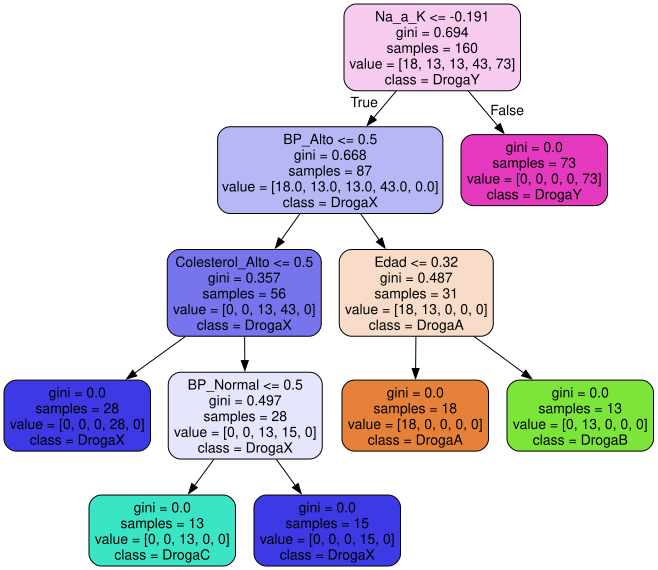

In [664]:
# Árbol de decisión - Clasificación 80/20 - Sin poda 
export_graphviz(
    best_tree_80,
    out_file="drug_tree_80_sin_poda.dot",
    feature_names=X_train_80_scaled.columns,
    class_names=best_tree_80.classes_,
    rounded=True,
    filled=True
)

Source.from_file("drug_tree_80_sin_poda.dot")

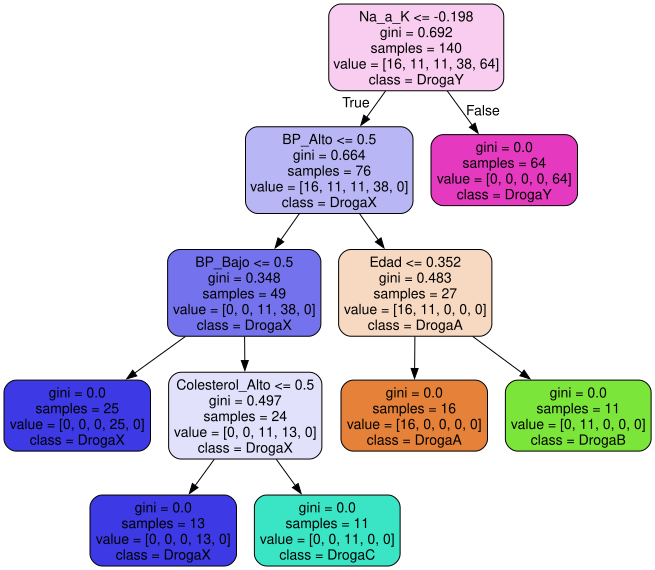

In [665]:
# Árbol de decisión - Clasificación 70/30 - Sin poda 

export_graphviz(
    best_tree_70,
    out_file="drug_tree_70_sin_poda.dot",
    feature_names=X_train_70_scaled.columns,
    class_names=best_tree_70.classes_,
    rounded=True,
    filled=True
)

Source.from_file("drug_tree_70_sin_poda.dot")

Al comparar los árboles sin poda de las particiones 80/20 y 70/30, observamos una estructura muy similar. En ambos casos, la primera división se realiza sobre 'Na_a_K', separando rápidamente a 'DrogaY' del resto de las clases.

Luego, el modelo utiliza principalmente variables asociadas a la presión arterial ('BP_Alto', 'BP_Bajo' o 'BP_Normal') y, en menor medida, 'Edad' y 'Colesterol_Alto'. Esto coincide con lo observado en el EDA, donde estas variables mostraban diferencias claras entre tipos de droga.

Como los árboles ya son interpretables, aplicamos la post-poda con 'ccp_alpha' para evaluar si podemos simplificar aún más la estructura sin perder demasiado desempeño.

In [666]:
# Post-poda 80/20 - Búsqueda de ccp_alpha

path_80 = best_tree_80.cost_complexity_pruning_path(X_train_80_scaled, y_train_80)

ccp_alphas_80 = path_80.ccp_alphas
impurities_80 = path_80.impurities

pd.DataFrame({
    "ccp_alpha": ccp_alphas_80,
    "impurity": impurities_80
})


,ccp_alpha,impurity
0,0.000000,0.000000
1,0.062388,0.124777
2,0.094355,0.219132
3,0.144230,0.363362
4,0.330388,0.693750


In [667]:
# Evaluación de ccp_alpha 80/20

resultados_poda_80 = []

for ccp_alpha in ccp_alphas_80:
    
    tree_poda = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=5,
        min_samples_split=2,
        random_state=63,
        ccp_alpha=ccp_alpha
    )
    
    tree_poda.fit(X_train_80_scaled, y_train_80)
    
    y_pred_poda = tree_poda.predict(X_test_20_scaled)
    
    resultados_poda_80.append({
        "ccp_alpha": ccp_alpha,
        "Precision": metrics.precision_score(y_test_20, y_pred_poda, average="macro", zero_division=0),
        "Recall": metrics.recall_score(y_test_20, y_pred_poda, average="macro", zero_division=0),
        "Accuracy": metrics.accuracy_score(y_test_20, y_pred_poda),
        "Nodos": tree_poda.tree_.node_count,
        "Profundidad": tree_poda.tree_.max_depth
    })

resultados_poda_80 = pd.DataFrame(resultados_poda_80)

resultados_poda_80

,ccp_alpha,Precision,Recall,Accuracy,Nodos,Profundidad
0,0.000000,1.000000,1.0,1.000,11,4
1,0.062388,0.757143,0.8,0.925,7,3
2,0.094355,0.482143,0.6,0.850,5,2
3,0.144230,0.300000,0.4,0.725,3,1
4,0.330388,0.090000,0.2,0.450,1,0


In [668]:
# Post-poda 70/30 - Búsqueda de ccp_alpha

path_70 = best_tree_70.cost_complexity_pruning_path(X_train_70_scaled, y_train_70)

ccp_alphas_70 = path_70.ccp_alphas
impurities_70 = path_70.impurities

pd.DataFrame({
    "ccp_alpha": ccp_alphas_70,
    "impurity": impurities_70
})

,ccp_alpha,impurity
0,0.000000,0.000000
1,0.060933,0.121866
2,0.093122,0.214988
3,0.145351,0.360338
4,0.331600,0.691939


In [669]:
# Evaluación de ccp_alpha 70/30 

resultados_poda_70 = []

for ccp_alpha in ccp_alphas_70:
    
    tree_poda = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=5,
        min_samples_split=2,
        random_state=63,
        ccp_alpha=ccp_alpha
    )
    
    tree_poda.fit(X_train_70_scaled, y_train_70)
    
    y_pred_poda = tree_poda.predict(X_test_30_scaled)
    
    resultados_poda_70.append({
        "ccp_alpha": ccp_alpha,
        "Precision": metrics.precision_score(y_test_30, y_pred_poda, average="macro", zero_division=0),
        "Recall": metrics.recall_score(y_test_30, y_pred_poda, average="macro", zero_division=0),
        "Accuracy": metrics.accuracy_score(y_test_30, y_pred_poda),
        "Nodos": tree_poda.tree_.node_count,
        "Profundidad": tree_poda.tree_.max_depth
    })

resultados_poda_70 = pd.DataFrame(resultados_poda_70)

resultados_poda_70

,ccp_alpha,Precision,Recall,Accuracy,Nodos,Profundidad
0,0.000000,1.000000,1.0,1.000000,11,4
1,0.060933,0.752381,0.8,0.916667,7,3
2,0.093122,0.469048,0.6,0.833333,5,2
3,0.145351,0.296970,0.4,0.716667,3,1
4,0.331600,0.090000,0.2,0.450000,1,0


A partir de las tablas anteriores, elegimos el primer valor positivo de 'ccp_alpha' en cada partición. Esta decisión permite aplicar una poda moderada: simplifica el árbol, pero evita una reducción demasiado fuerte de la estructura.

In [670]:
# Elegimos el primer valor positivo de ccp_alpha en cada partición
ccp_alpha_80 = ccp_alphas_80[ccp_alphas_80 > 0][0]
ccp_alpha_70 = ccp_alphas_70[ccp_alphas_70 > 0][0]

print("ccp_alpha 80/20:", ccp_alpha_80)
print("ccp_alpha 70/30:", ccp_alpha_70)

ccp_alpha 80/20: 0.06238839285714286
ccp_alpha 70/30: 0.060932944606414


In [671]:
# Árbol de decisión - Clasificación 80/20 - Con poda 

tree_poda_80 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=63,
    ccp_alpha=ccp_alpha_80
)

tree_poda_80.fit(X_train_80_scaled, y_train_80)

y_pred_poda_80 = tree_poda_80.predict(X_test_20_scaled)

In [672]:
# Árbol de decisión - Clasificación 70/30 - Con poda 

tree_poda_70 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=63,
    ccp_alpha=ccp_alpha_70
)

tree_poda_70.fit(X_train_70_scaled, y_train_70)

y_pred_poda_70 = tree_poda_70.predict(X_test_30_scaled)

In [673]:
metricas_tree_poda = pd.DataFrame({
    "Partición": ["80/20", "70/30"],
    "ccp_alpha": [ccp_alpha_80, ccp_alpha_70],
    "Precision": [
        metrics.precision_score(y_test_20, y_pred_poda_80, average="macro", zero_division=0),
        metrics.precision_score(y_test_30, y_pred_poda_70, average="macro", zero_division=0)
    ],
    "Recall": [
        metrics.recall_score(y_test_20, y_pred_poda_80, average="macro", zero_division=0),
        metrics.recall_score(y_test_30, y_pred_poda_70, average="macro", zero_division=0)
    ],
    "Accuracy": [
        metrics.accuracy_score(y_test_20, y_pred_poda_80),
        metrics.accuracy_score(y_test_30, y_pred_poda_70)
    ],
    "Nodos": [
        tree_poda_80.tree_.node_count,
        tree_poda_70.tree_.node_count
    ],
    "Profundidad": [
        tree_poda_80.tree_.max_depth,
        tree_poda_70.tree_.max_depth
    ]
})

metricas_tree_poda

,Partición,ccp_alpha,Precision,Recall,Accuracy,Nodos,Profundidad
0,80/20,0.062388,0.757143,0.8,0.925000,7,3
1,70/30,0.060933,0.752381,0.8,0.916667,7,3


Al evaluar la post-poda por separado en ambas particiones, observamos un comportamiento muy similar. En los dos casos, el primer valor positivo de 'ccp_alpha' reduce el árbol de 11 a 7 nodos y baja la profundidad de 4 a 3.

Esta poda simplifica la estructura del modelo, pero también genera una disminución en las métricas. En la partición 80/20, el accuracy queda en 0.925, mientras que en la partición 70/30 queda en 0.917. Aun así, el desempeño general sigue siendo alto.

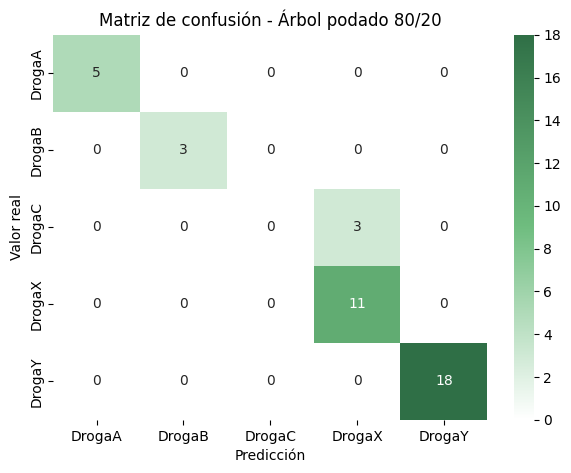

In [674]:
# Matriz de confusión - Árbol podado 80/20 

cm_poda_80 = metrics.confusion_matrix(y_test_20, y_pred_poda_80)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_poda_80,
    annot=True,
    fmt="d",
    cmap=cmap_confusion,
    vmin=0,
    vmax=cm_poda_80.max(),
    xticklabels=tree_poda_80.classes_,
    yticklabels=tree_poda_80.classes_
)

plt.title("Matriz de confusión - Árbol podado 80/20")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

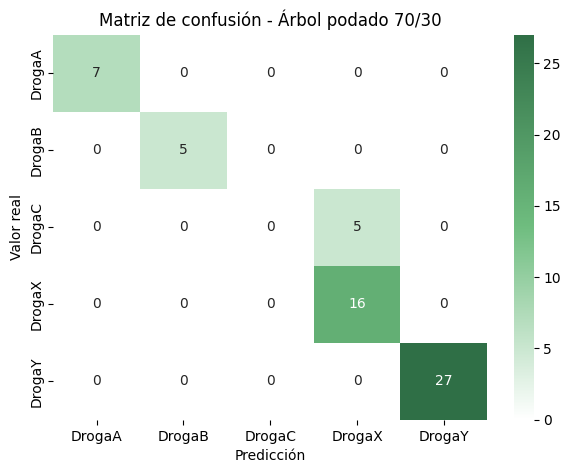

In [675]:
# Matriz de confusión - Árbol podado 70/30 

cm_poda_70 = metrics.confusion_matrix(y_test_30, y_pred_poda_70)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_poda_70,
    annot=True,
    fmt="d",
    cmap=cmap_confusion,
    vmin=0,
    vmax=cm_poda_70.max(),
    xticklabels=tree_poda_70.classes_,
    yticklabels=tree_poda_70.classes_
)

plt.title("Matriz de confusión - Árbol podado 70/30")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

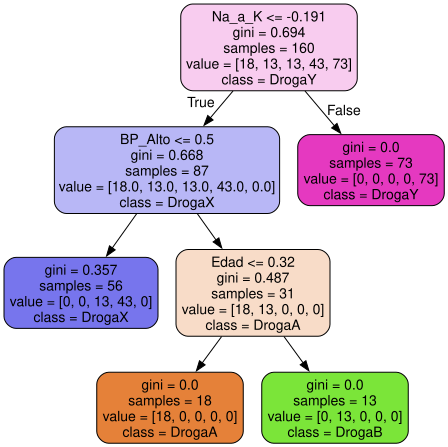

In [676]:
# Árbol de decisión - Clasificación 80/20 - Después de la poda 

export_graphviz(
    tree_poda_80,
    out_file="drug_tree_80_con_poda.dot",
    feature_names=X_train_80_scaled.columns,
    class_names=tree_poda_80.classes_,
    rounded=True,
    filled=True
)

Source.from_file("drug_tree_80_con_poda.dot")

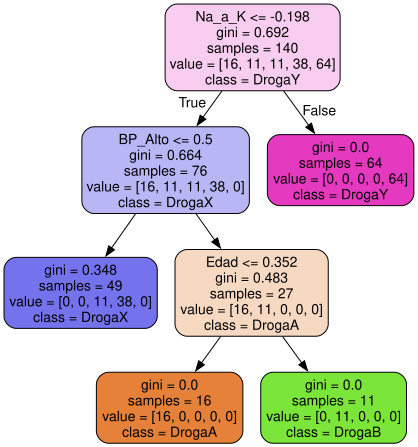

In [677]:
# Árbol de decisión - Clasificación 70/30 - Después de la poda 

export_graphviz(
    tree_poda_70,
    out_file="drug_tree_70_con_poda.dot",
    feature_names=X_train_70_scaled.columns,
    class_names=tree_poda_70.classes_,
    rounded=True,
    filled=True
)

Source.from_file("drug_tree_70_con_poda.dot")

Las matrices de confusión muestran que, luego de la poda, el modelo sigue clasificando correctamente la mayoría de las clases. 'DrogaA', 'DrogaB', 'DrogaX' y 'DrogaY' se mantienen bien identificadas en ambas particiones.

El principal efecto de la poda aparece en 'DrogaC', que pasa a ser clasificada como 'DrogaX'. Esto se entiende al observar los árboles podados: al simplificarse la estructura, desaparecen algunas divisiones que antes permitían separar mejor estas clases, especialmente las relacionadas con colesterol.

Por lo tanto, la poda logra un árbol más simple e interpretable, pero con una pérdida puntual en la clasificación de 'DrogaC'.

En conclusión, el árbol sin poda obtuvo el mejor desempeño, con 'Precision', 'Recall' y 'Accuracy' iguales a 1.0 en ambas particiones. Además, su estructura no resultó excesivamente compleja, ya que mantuvo una profundidad máxima de 4 y reglas interpretables.

La post-poda con 'ccp_alpha' permitió simplificar el modelo, reduciendo la cantidad de nodos y la profundidad del árbol. Sin embargo, esta simplificación produjo una pérdida de desempeño, especialmente por la confusión de 'DrogaC' con 'DrogaX'.

Por este motivo, consideramos que el árbol sin poda es la mejor alternativa para este dataset. La poda resulta útil para observar el efecto de simplificar la estructura, pero en este caso no mejora el modelo final, ya que elimina divisiones que aportaban información relevante para separar correctamente todas las clases.

### Naive Bayes

En este punto estimamos la variable 'Droga' utilizando Naive Bayes. Como el modelo categórico requiere variables discretas, trabajamos con una preparación distinta a la usada en árboles de decisión.

Discretizamos las variables numéricas 'Edad' y 'Na_a_K' mediante cuantiles, probando 3 y 5 intervalos. Esta estrategia permite transformar variables continuas en categorías con frecuencias similares. Además, codificamos las variables categóricas predictoras para que puedan ser utilizadas por el modelo.

In [678]:
# Separamos variables predictoras y variable objetivo
X_nb = dataDrug.drop("Droga", axis=1)
y_nb = dataDrug["Droga"]

# Identificamos variables numéricas y categóricas
numeric_features_nb = ["Edad", "Na_a_K"]
categorical_features_nb = ["Sexo", "BP", "Colesterol"]

Generamos nuevamente las particiones 80/20 y 70/30, pero ahora a partir del dataset sin transformaciones previas. Mantenemos 'random_state=63' y utilizamos estratificación por 'Droga', ya que en el EDA observamos cierto desbalance entre las clases.

In [679]:
# Partición 80/20
X_train_80_nb, X_test_20_nb, y_train_80_nb, y_test_20_nb = train_test_split(
    X_nb,
    y_nb,
    test_size=0.20,
    random_state=63,
    stratify=y_nb
)

# Partición 70/30
X_train_70_nb, X_test_30_nb, y_train_70_nb, y_test_30_nb = train_test_split(
    X_nb,
    y_nb,
    test_size=0.30,
    random_state=63,
    stratify=y_nb
)

In [680]:
# Codificación categórica para la partición 80/20
encoder_80 = OrdinalEncoder()

X_train_80_cat = encoder_80.fit_transform(X_train_80_nb[categorical_features_nb])
X_test_20_cat = encoder_80.transform(X_test_20_nb[categorical_features_nb])

# Codificación categórica para la partición 70/30
encoder_70 = OrdinalEncoder()

X_train_70_cat = encoder_70.fit_transform(X_train_70_nb[categorical_features_nb])
X_test_30_cat = encoder_70.transform(X_test_30_nb[categorical_features_nb])

In [681]:
# Discretización con 3 intervalos para 80/20
discretizer_80_3 = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf"
)

X_train_80_num_3 = discretizer_80_3.fit_transform(X_train_80_nb[numeric_features_nb])
X_test_20_num_3 = discretizer_80_3.transform(X_test_20_nb[numeric_features_nb])


# Discretización con 5 intervalos para 80/20
discretizer_80_5 = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf"
)

X_train_80_num_5 = discretizer_80_5.fit_transform(X_train_80_nb[numeric_features_nb])
X_test_20_num_5 = discretizer_80_5.transform(X_test_20_nb[numeric_features_nb])

In [682]:
# Discretización con 3 intervalos para 70/30
discretizer_70_3 = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf"
)

X_train_70_num_3 = discretizer_70_3.fit_transform(X_train_70_nb[numeric_features_nb])
X_test_30_num_3 = discretizer_70_3.transform(X_test_30_nb[numeric_features_nb])


# Discretización con 5 intervalos para 70/30
discretizer_70_5 = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf"
)

X_train_70_num_5 = discretizer_70_5.fit_transform(X_train_70_nb[numeric_features_nb])
X_test_30_num_5 = discretizer_70_5.transform(X_test_30_nb[numeric_features_nb])

Al discretizar 'Edad' y 'Na_a_K' mediante cuantiles, especificamos el parámetro 'quantile_method="averaged_inverted_cdf"'. Esto evita warnings de compatibilidad futura de 'scikit-learn' y mantiene la prolijidad del notebook.

In [683]:
# Dataset preparado para Naive Bayes - 80/20 con 3 intervalos
X_train_80_nb_3 = np.concatenate([X_train_80_num_3, X_train_80_cat], axis=1)
X_test_20_nb_3 = np.concatenate([X_test_20_num_3, X_test_20_cat], axis=1)

# Dataset preparado para Naive Bayes - 80/20 con 5 intervalos
X_train_80_nb_5 = np.concatenate([X_train_80_num_5, X_train_80_cat], axis=1)
X_test_20_nb_5 = np.concatenate([X_test_20_num_5, X_test_20_cat], axis=1)

# Dataset preparado para Naive Bayes - 70/30 con 3 intervalos
X_train_70_nb_3 = np.concatenate([X_train_70_num_3, X_train_70_cat], axis=1)
X_test_30_nb_3 = np.concatenate([X_test_30_num_3, X_test_30_cat], axis=1)

# Dataset preparado para Naive Bayes - 70/30 con 5 intervalos
X_train_70_nb_5 = np.concatenate([X_train_70_num_5, X_train_70_cat], axis=1)
X_test_30_nb_5 = np.concatenate([X_test_30_num_5, X_test_30_cat], axis=1)

Con estas transformaciones dejamos preparados cuatro conjuntos de datos para Bayes Ingenuo: dos para la partición 80/20 y dos para la partición 70/30, en cada caso con 3 y 5 intervalos.

In [684]:
# Naive Bayes - CategoricalNB 80/20 - 3 intervalos 

model_nb_80_3 = CategoricalNB()
model_nb_80_3.fit(X_train_80_nb_3, y_train_80_nb)

y_pred_nb_80_3 = model_nb_80_3.predict(X_test_20_nb_3)


# Naive Bayes - CategoricalNB 80/20 - 5 intervalos 

model_nb_80_5 = CategoricalNB()
model_nb_80_5.fit(X_train_80_nb_5, y_train_80_nb)

y_pred_nb_80_5 = model_nb_80_5.predict(X_test_20_nb_5)


# Naive Bayes - CategoricalNB 70/30 - 3 intervalos 

model_nb_70_3 = CategoricalNB()
model_nb_70_3.fit(X_train_70_nb_3, y_train_70_nb)

y_pred_nb_70_3 = model_nb_70_3.predict(X_test_30_nb_3)


# Naive Bayes - CategoricalNB 70/30 - 5 intervalos 

model_nb_70_5 = CategoricalNB()
model_nb_70_5.fit(X_train_70_nb_5, y_train_70_nb)

y_pred_nb_70_5 = model_nb_70_5.predict(X_test_30_nb_5)

Para comparar los resultados de forma más clara, reunimos las métricas de las cuatro pruebas en una misma tabla. Observamos 'Precision' y 'Recall' macro porque la variable objetivo no está completamente balanceada, y también 'Accuracy' para tener una medida general de aciertos.

In [685]:
metricas_nb = pd.DataFrame({
    "Partición": ["80/20", "80/20", "70/30", "70/30"],
    "Intervalos": [3, 5, 3, 5],
    "Modelo": ["CategoricalNB", "CategoricalNB", "CategoricalNB", "CategoricalNB"],
    "Precision": [
        metrics.precision_score(y_test_20_nb, y_pred_nb_80_3, average="macro", zero_division=0),
        metrics.precision_score(y_test_20_nb, y_pred_nb_80_5, average="macro", zero_division=0),
        metrics.precision_score(y_test_30_nb, y_pred_nb_70_3, average="macro", zero_division=0),
        metrics.precision_score(y_test_30_nb, y_pred_nb_70_5, average="macro", zero_division=0)
    ],
    "Recall": [
        metrics.recall_score(y_test_20_nb, y_pred_nb_80_3, average="macro", zero_division=0),
        metrics.recall_score(y_test_20_nb, y_pred_nb_80_5, average="macro", zero_division=0),
        metrics.recall_score(y_test_30_nb, y_pred_nb_70_3, average="macro", zero_division=0),
        metrics.recall_score(y_test_30_nb, y_pred_nb_70_5, average="macro", zero_division=0)
    ],
    "Accuracy": [
        metrics.accuracy_score(y_test_20_nb, y_pred_nb_80_3),
        metrics.accuracy_score(y_test_20_nb, y_pred_nb_80_5),
        metrics.accuracy_score(y_test_30_nb, y_pred_nb_70_3),
        metrics.accuracy_score(y_test_30_nb, y_pred_nb_70_5)
    ]
})

metricas_nb

,Partición,Intervalos,Modelo,Precision,Recall,Accuracy
0,80/20,3,CategoricalNB,0.830476,0.811111,0.825000
1,80/20,5,CategoricalNB,0.926190,0.966667,0.925000
2,70/30,3,CategoricalNB,0.902126,0.830463,0.850000
3,70/30,5,CategoricalNB,0.900000,0.962963,0.916667


Al comparar los resultados de Bayes Ingenuo, observamos que el modelo con 5 intervalos obtiene mejores métricas que el modelo con 3 intervalos en ambas particiones.

En la partición 80/20, el modelo con 5 intervalos alcanza un 'Accuracy' de 0.925, con valores altos de 'Precision' y 'Recall'. En la partición 70/30 ocurre algo similar, con un 'Accuracy' de 0.917 y un 'Recall' macro elevado.

Esta diferencia sugiere que una discretización más detallada de 'Edad' y 'Na_a_K' permite conservar mejor la información necesaria para clasificar 'Droga'. Por este motivo, seleccionamos los modelos con 5 intervalos para analizar las matrices de confusión.

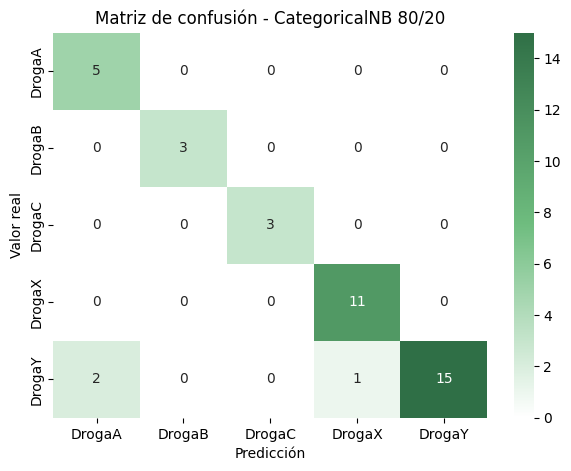

In [686]:
# Matriz de confusión - CategoricalNB 80/20 - 5 intervalos 

cm_nb_80_5 = metrics.confusion_matrix(y_test_20_nb, y_pred_nb_80_5)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb_80_5,
    annot=True,
    fmt="d",
    cmap=cmap_confusion,
    vmin=0,
    vmax=cm_nb_80_5.max(),
    xticklabels=model_nb_80_5.classes_,
    yticklabels=model_nb_80_5.classes_
)

plt.title("Matriz de confusión - CategoricalNB 80/20")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

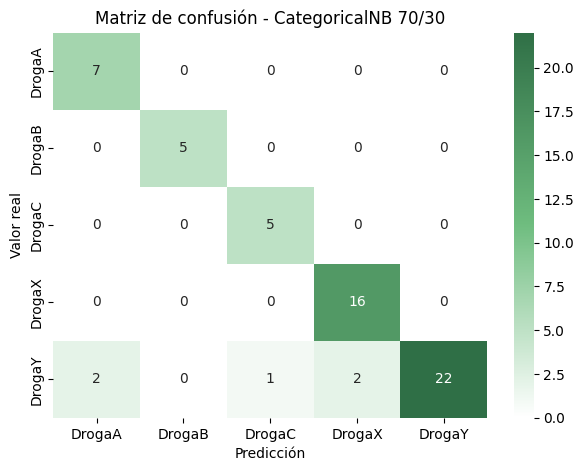

In [687]:
# Matriz de confusión - CategoricalNB 70/30 - 5 intervalos 

cm_nb_70_5 = metrics.confusion_matrix(y_test_30_nb, y_pred_nb_70_5)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb_70_5,
    annot=True,
    fmt="d",
    cmap=cmap_confusion,
    vmin=0,
    vmax=cm_nb_70_5.max(),
    xticklabels=model_nb_70_5.classes_,
    yticklabels=model_nb_70_5.classes_
)

plt.title("Matriz de confusión - CategoricalNB 70/30")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

Al analizar las matrices de confusión de 'CategoricalNB' con 5 intervalos, observamos que el modelo clasifica correctamente la mayoría de las observaciones. Las clases 'DrogaA', 'DrogaB', 'DrogaC' y 'DrogaX' quedan bien identificadas en ambas particiones.

Los errores se concentran principalmente en 'DrogaY', que en algunos casos es clasificada como 'DrogaA', 'DrogaX' o 'DrogaC'. Esto puede deberse a que 'DrogaY' es la clase más frecuente y también la que presenta mayor variabilidad interna, especialmente en relación con 'Na_a_K'.

En comparación con la discretización de 3 intervalos, el uso de 5 intervalos conserva mejor la información de las variables numéricas y mejora las métricas en ambas particiones. Por este motivo, tomamos 'CategoricalNB' con 5 intervalos como la mejor configuración de Bayes Ingenuo para este dataset.

En conclusión, Bayes Ingenuo logra un desempeño alto, especialmente con 5 intervalos. Aunque no alcanza el rendimiento perfecto del árbol de decisión, mantiene buenas métricas y una interpretación simple.

### k-NN

En este punto estimamos la variable 'Droga' utilizando k-NN. A diferencia del árbol de decisión, este modelo se basa en distancias entre observaciones, por lo que trabajamos con las variables numéricas previamente estandarizadas.

Exploramos distintos valores de 'n_neighbors' y dos métricas de distancia: euclidiana y Manhattan. En cada combinación calculamos 'Precision', 'Recall' y 'Accuracy', manteniendo la evaluación sobre las particiones 80/20 y 70/30.

In [688]:
# k-NN - Clasificación 80/20 - Hiperparámetros 

resultados_knn_80 = []

n_neighbors_values = [1, 3, 5, 7, 9]
metric_values = ["euclidean", "manhattan"]

for n_neighbors in n_neighbors_values:
    for metric in metric_values:
        
        knn_model = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            metric=metric
        )
        
        knn_model.fit(X_train_80_scaled, y_train_80)
        
        y_pred_knn = knn_model.predict(X_test_20_scaled)
        
        resultados_knn_80.append({
            "n_neighbors": n_neighbors,
            "metric": metric,
            "Precision": metrics.precision_score(y_test_20, y_pred_knn, average="macro", zero_division=0),
            "Recall": metrics.recall_score(y_test_20, y_pred_knn, average="macro", zero_division=0),
            "Accuracy": metrics.accuracy_score(y_test_20, y_pred_knn)
        })

resultados_knn_80 = pd.DataFrame(resultados_knn_80)

resultados_knn_80.sort_values(
    by=["Accuracy", "Recall", "Precision"],
    ascending=False
)

,n_neighbors,metric,Precision,Recall,Accuracy
8,9,euclidean,0.935897,0.966667,0.925
6,7,euclidean,0.916731,0.926667,0.900
1,1,manhattan,0.870000,0.937374,0.875
0,1,euclidean,0.813333,0.897374,0.850
2,3,euclidean,0.854167,0.922222,0.825
3,3,manhattan,0.854167,0.922222,0.825
9,9,manhattan,0.830833,0.882222,0.800
4,5,euclidean,0.824286,0.875152,0.800
5,5,manhattan,0.775000,0.786263,0.725
7,7,manhattan,0.772179,0.786263,0.725


In [689]:
# k-NN - Clasificación 70/30 - Hiperparámetros 

resultados_knn_70 = []

for n_neighbors in n_neighbors_values:
    for metric in metric_values:
        
        knn_model = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            metric=metric
        )
        
        knn_model.fit(X_train_70_scaled, y_train_70)
        
        y_pred_knn = knn_model.predict(X_test_30_scaled)
        
        resultados_knn_70.append({
            "n_neighbors": n_neighbors,
            "metric": metric,
            "Precision": metrics.precision_score(y_test_30, y_pred_knn, average="macro", zero_division=0),
            "Recall": metrics.recall_score(y_test_30, y_pred_knn, average="macro", zero_division=0),
            "Accuracy": metrics.accuracy_score(y_test_30, y_pred_knn)
        })

resultados_knn_70 = pd.DataFrame(resultados_knn_70)

resultados_knn_70.sort_values(
    by=["Accuracy", "Recall", "Precision"],
    ascending=False
)

,n_neighbors,metric,Precision,Recall,Accuracy
1,1,manhattan,0.867495,0.921892,0.883333
8,9,euclidean,0.919000,0.850370,0.883333
3,3,manhattan,0.887121,0.940741,0.866667
2,3,euclidean,0.853788,0.933333,0.850000
0,1,euclidean,0.830952,0.853320,0.850000
6,7,euclidean,0.844990,0.806984,0.833333
4,5,euclidean,0.766190,0.804854,0.766667
9,9,manhattan,0.791111,0.769947,0.750000
7,7,manhattan,0.778856,0.757447,0.733333
5,5,manhattan,0.716364,0.717447,0.716667


Al explorar los hiperparámetros de k-NN observamos que la mejor configuración cambia según la partición utilizada.

En la partición 80/20, el mejor resultado se obtiene con 'n_neighbors=9' y distancia euclidiana, alcanzando un 'Accuracy' de 0.925. En cambio, para la partición 70/30, la mejor combinación es 'n_neighbors=1' con distancia Manhattan, con un 'Accuracy' aproximado de 0.883.

Esta diferencia muestra que k-NN es sensible tanto a la partición de los datos como a la elección de la métrica de distancia y la cantidad de vecinos. Aun así, en ambas particiones el modelo mantiene un desempeño aceptable, aunque inferior al árbol de decisión.

In [690]:
# k-NN - Mejor modelo 80/20 

best_knn_80 = KNeighborsClassifier(
    n_neighbors=9,
    metric="euclidean"
)

best_knn_80.fit(X_train_80_scaled, y_train_80)

y_pred_knn_80 = best_knn_80.predict(X_test_20_scaled)

In [691]:
# k-NN - Mejor modelo 70/30 

best_knn_70 = KNeighborsClassifier(
    n_neighbors=1,
    metric="manhattan"
)

best_knn_70.fit(X_train_70_scaled, y_train_70)

y_pred_knn_70 = best_knn_70.predict(X_test_30_scaled)

In [692]:
metricas_knn = pd.DataFrame({
    "Partición": ["80/20", "70/30"],
    "n_neighbors": [9, 1],
    "metric": ["euclidean", "manhattan"],
    "Precision": [
        metrics.precision_score(y_test_20, y_pred_knn_80, average="macro", zero_division=0),
        metrics.precision_score(y_test_30, y_pred_knn_70, average="macro", zero_division=0)
    ],
    "Recall": [
        metrics.recall_score(y_test_20, y_pred_knn_80, average="macro", zero_division=0),
        metrics.recall_score(y_test_30, y_pred_knn_70, average="macro", zero_division=0)
    ],
    "Accuracy": [
        metrics.accuracy_score(y_test_20, y_pred_knn_80),
        metrics.accuracy_score(y_test_30, y_pred_knn_70)
    ]
})

metricas_knn

,Partición,n_neighbors,metric,Precision,Recall,Accuracy
0,80/20,9,euclidean,0.935897,0.966667,0.925000
1,70/30,1,manhattan,0.867495,0.921892,0.883333


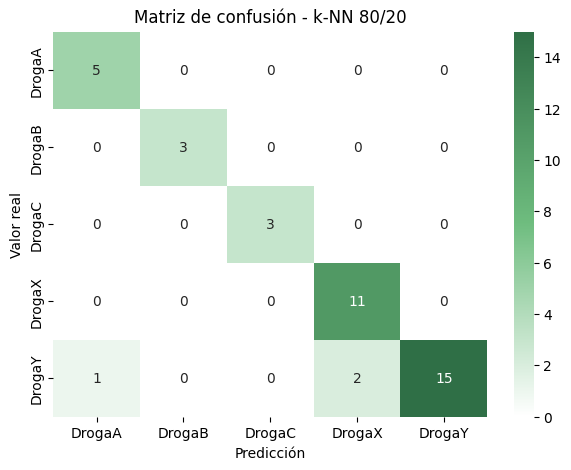

In [693]:
# Matriz de confusión - k-NN 80/20 

cm_knn_80 = metrics.confusion_matrix(y_test_20, y_pred_knn_80)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn_80,
    annot=True,
    fmt="d",
    cmap=cmap_confusion,
    vmin=0,
    vmax=cm_knn_80.max(),
    xticklabels=best_knn_80.classes_,
    yticklabels=best_knn_80.classes_
)

plt.title("Matriz de confusión - k-NN 80/20")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

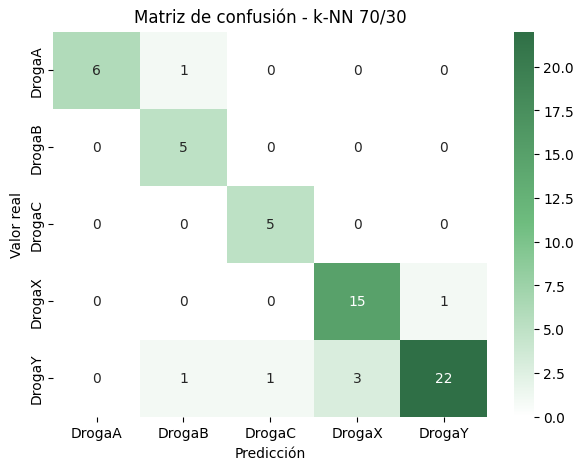

In [694]:
# Matriz de confusión - k-NN 70/30 

cm_knn_70 = metrics.confusion_matrix(y_test_30, y_pred_knn_70)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn_70,
    annot=True,
    fmt="d",
    cmap=cmap_confusion,
    vmin=0,
    vmax=cm_knn_70.max(),
    xticklabels=best_knn_70.classes_,
    yticklabels=best_knn_70.classes_
)

plt.title("Matriz de confusión - k-NN 70/30")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

Las matrices de confusión muestran que el modelo clasifica correctamente la mayoría de las observaciones, especialmente en las clases 'DrogaA', 'DrogaB', 'DrogaC' y buena parte de 'DrogaX' y 'DrogaY'. Los errores aparecen principalmente en 'DrogaY', que en algunos casos se clasifica como 'DrogaA', 'DrogaB', 'DrogaC' o 'DrogaX', según la partición. En la partición 70/30 también observamos un caso de 'DrogaA' clasificado como 'DrogaB' y un caso de 'DrogaX' clasificado como 'DrogaY'.

En comparación con el árbol de decisión, k-NN no alcanza una clasificación perfecta y muestra mayor sensibilidad a la partición de los datos y a la elección de la métrica de distancia. Aun así, mantiene un desempeño alto, especialmente en la partición 80/20.

### Comparación de modelos

Para cerrar la parte de clasificación, comparamos los mejores resultados obtenidos con los tres algoritmos trabajados: árbol de decisión, Naive Bayes y k-NN.

En cada caso tomamos la mejor configuración encontrada para las particiones 80/20 y 70/30. Esta comparación nos permite evaluar no solo las métricas obtenidas, sino también la estabilidad del modelo y su interpretabilidad.

In [695]:
# Árbol de decisión: usamos el mejor árbol sin poda
comparacion_tree = metricas_tree.copy()

comparacion_tree["Modelo"] = "Árbol de decisión"
comparacion_tree["Mejor configuración"] = (
    "max_depth=" + str(best_tree_80.get_params()["max_depth"]) +
    ", min_samples_leaf=" + str(best_tree_80.get_params()["min_samples_leaf"]) +
    ", min_samples_split=" + str(best_tree_80.get_params()["min_samples_split"])
)

comparacion_tree = comparacion_tree[
    ["Modelo", "Partición", "Mejor configuración", "Precision", "Recall", "Accuracy"]
]

In [696]:
# Bayes Ingenuo: seleccionamos la mejor configuración por partición
comparacion_nb = metricas_nb.sort_values(
    by=["Partición", "Accuracy", "Recall", "Precision"],
    ascending=[True, False, False, False]
).groupby("Partición").head(1).copy()

comparacion_nb["Modelo"] = "Naive Bayes"
comparacion_nb["Mejor configuración"] = (
    comparacion_nb["Modelo"].astype(str) +
    ", " +
    comparacion_nb["Intervalos"].astype(str) +
    " intervalos"
)

comparacion_nb = comparacion_nb[
    ["Modelo", "Partición", "Mejor configuración", "Precision", "Recall", "Accuracy"]
]

In [697]:
# k-NN: usamos la tabla de mejores modelos por partición
comparacion_knn = metricas_knn.copy()

comparacion_knn["Modelo"] = "k-NN"
comparacion_knn["Mejor configuración"] = (
    "k=" + comparacion_knn["n_neighbors"].astype(str) +
    ", " +
    comparacion_knn["metric"].astype(str)
)

comparacion_knn = comparacion_knn[
    ["Modelo", "Partición", "Mejor configuración", "Precision", "Recall", "Accuracy"]
]

In [698]:
# Unimos las tres comparaciones
comparacion_modelos = pd.concat(
    [comparacion_tree, comparacion_nb, comparacion_knn],
    ignore_index=True
)

comparacion_modelos

,Modelo,Partición,Mejor configuración,Precision,Recall,Accuracy
0,Árbol de decisión,80/20,"max_depth=4, min_samples_leaf=5, min_samples_s...",1.000000,1.000000,1.000000
1,Árbol de decisión,70/30,"max_depth=4, min_samples_leaf=5, min_samples_s...",1.000000,1.000000,1.000000
2,Naive Bayes,70/30,"Naive Bayes, 5 intervalos",0.900000,0.962963,0.916667
3,Naive Bayes,80/20,"Naive Bayes, 5 intervalos",0.926190,0.966667,0.925000
4,k-NN,80/20,"k=9, euclidean",0.935897,0.966667,0.925000
5,k-NN,70/30,"k=1, manhattan",0.867495,0.921892,0.883333


Para construir la tabla comparativa reutilizamos las tablas generadas en cada modelo. De esta manera evitamos errores de transcripción y mantenemos la comparación vinculada directamente con los resultados obtenidos durante el entrenamiento.

En cada algoritmo tomamos la mejor configuración encontrada para cada partición y reunimos 'Precision', 'Recall' y 'Accuracy' en una única tabla.

Al comparar los tres modelos, observamos que el árbol de decisión sin poda obtiene el mejor desempeño en ambas particiones, con 'Precision', 'Recall' y 'Accuracy' iguales a 1.0. Además, mantiene estos resultados tanto en 80/20 como en 70/30, lo que indica una mayor estabilidad frente al cambio en la proporción de entrenamiento y prueba.

Naive Bayes también alcanza métricas altas, especialmente al discretizar las variables numéricas en 5 intervalos. Sin embargo, presenta algunos errores concentrados en 'DrogaY', que en ciertos casos se clasifica como otras drogas. k-NN, por su parte, logra un buen rendimiento en 80/20, pero disminuye en 70/30, lo que muestra una mayor sensibilidad a la partición y a la configuración de vecinos y distancia.

Considerando las métricas, el árbol de decisión es el modelo más adecuado para este problema. A esto se suma su interpretabilidad: pudimos visualizar reglas claras basadas principalmente en 'Na_a_K', 'BP', 'Edad' y 'Colesterol', variables que ya habían mostrado relevancia durante el análisis exploratorio.

Por este motivo, seleccionamos el árbol de decisión sin poda como modelo final. La poda permitió simplificar la estructura, pero también eliminó divisiones útiles para diferenciar algunas clases, especialmente 'DrogaC'. En este caso, conservar el árbol sin poda resulta más conveniente, ya que mantiene una estructura interpretable y clasifica correctamente todas las observaciones evaluadas.

### Conclusión

En esta segunda parte trabajamos con un problema de clasificación para estimar la variable 'Droga'. A partir del EDA observamos que el dataset no presentaba valores faltantes ni duplicados, pero sí cierto desbalance entre clases, especialmente por la mayor presencia de 'DrogaY'.

Al comparar los modelos, el árbol de decisión fue el que mostró el mejor desempeño y la mayor claridad interpretativa. Naive Bayes y k-NN también obtuvieron resultados aceptables, aunque presentaron más errores, principalmente en la clasificación de 'DrogaY'.

En función de las métricas obtenidas y de la posibilidad de interpretar sus reglas, consideramos que el árbol de decisión sin poda es el modelo más adecuado para este problema.